# лабораторная работа 1
## arima для временного ряда

задача работы:
- подобрать модель `arima`
- настроитб параметры

- построить прогноз на 4 года вперед;
- дополнительно проверить модель на последних 4 известных значениях ряда.

In [5]:
%matplotlib inline

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
pd.options.display.float_format = '{:,.3f}'.format

## готовим ряд

в исходном файле две колонки:
- первая колонка номер наблюдения;
- вторая колонка значение ряда.

так как стартовый календарный год не указан, укажем порядок просто

In [13]:
raw_data = pd.read_csv('M3_152_0.csv', header=None, names=['ind', 'value'])

# перевожу индекс ряда в удобный порядок
raw_data['year_number'] = np.arange(1, len(raw_data) + 1)

series = pd.Series(
    raw_data['value'].astype(float).values,
    index=raw_data['year_number'],
    name='value',
)

In [14]:

# последние 4 наблюдения откладываю для проверки качества
train = series.iloc[:-4].copy()
valid = series.iloc[-4:].copy()

In [15]:
len(series)

38

In [16]:
len(train)

34

In [17]:
len(valid)

4

In [18]:
raw_data.head()

,ind,value,year_number
0,0,"5,717.000",1
1,1,"6,374.000",2
2,2,"5,837.500",3
3,3,"7,318.400",4
4,4,"4,613.000",5


In [19]:
raw_data.tail()

,ind,value,year_number
33,33,"5,861.500",34
34,34,"6,346.700",35
35,35,"6,606.100",36
36,36,"6,762.700",37
37,37,"7,507.400",38


## сначала просто смотрим на данные

перед подбором модели полезно увидеть форму ряда глазами:
есть ли общий рост, есть ли резкие скачки, насколько спокойно ведет себя последняя часть.

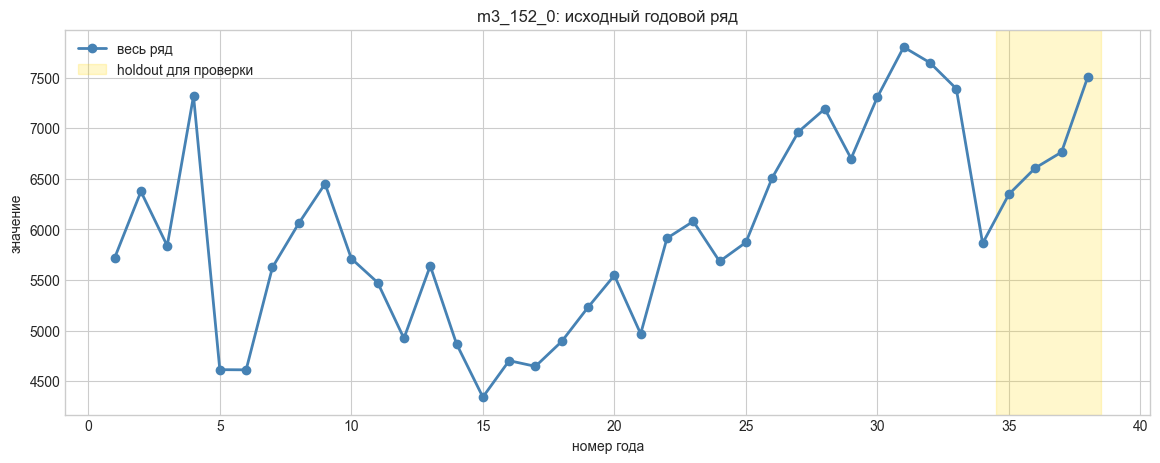

In [20]:
plt.figure(figsize=(14, 5))

plt.plot(
    series.index,
    series.values,
    marker='o',
    linewidth=2,
    color='steelblue',
    label='весь ряд',
)

# подсвечиваю те 4 точки, которые временно убрал из обучения
plt.axvspan(
    valid.index[0] - 0.5,
    valid.index[-1] + 0.5,
    color='gold',
    alpha=0.2,
    label='holdout для проверки',
)

plt.title('m3_152_0: исходный годовой ряд')
plt.xlabel('номер года')
plt.ylabel('значение')
plt.legend()
plt.show()

модель `arima(p, d, q)` состоит из трех частей:
- `p` autoregression, то есть зависимость от прошлых значений ряда;
- `d` differencing, то есть сколько раз берем разности;
- `q` moving average, то есть зависимость от прошлых ошибок модели

In [21]:
def make_adf_row(values, row_name):
    clean_values = values.dropna()
    adf_stat, p_value, _, _, _, _ = adfuller(clean_values, autolag='AIC')

    return {
        'ряд': row_name,
        'наблюдений': len(clean_values),
        'adf-статистика': adf_stat,
        'p-value': p_value,
    }


diff_1 = series.diff()
diff_2 = series.diff().diff()

adf_table = pd.DataFrame(
    [
        make_adf_row(series, 'исходный ряд'),
        make_adf_row(diff_1, 'первая разность, d=1'),
        make_adf_row(diff_2, 'вторая разность, d=2'),
    ]
)

display(adf_table)

print(
    'по adf-тесту исходный ряд нестационарный, '
    'а после первой разности уже становится гораздо спокойнее.'
)

,ряд,наблюдений,adf-статистика,p-value
0,исходный ряд,38,-2.238,0.193
1,"первая разность, d=1",37,-7.727,0.000
2,"вторая разность, d=2",36,-6.266,0.000


по adf-тесту исходный ряд нестационарный, а после первой разности уже становится гораздо спокойнее.


## смотрим на разности, acf и pacf

после первой разности ряд уже можно анализировать как кандидата для `arima`.
здесь:
- `acf` показывает общую автокорреляцию;
- `pacf` показывает частичную автокорреляцию;
- по ним удобно наметить разумные значения `p` и `q`.

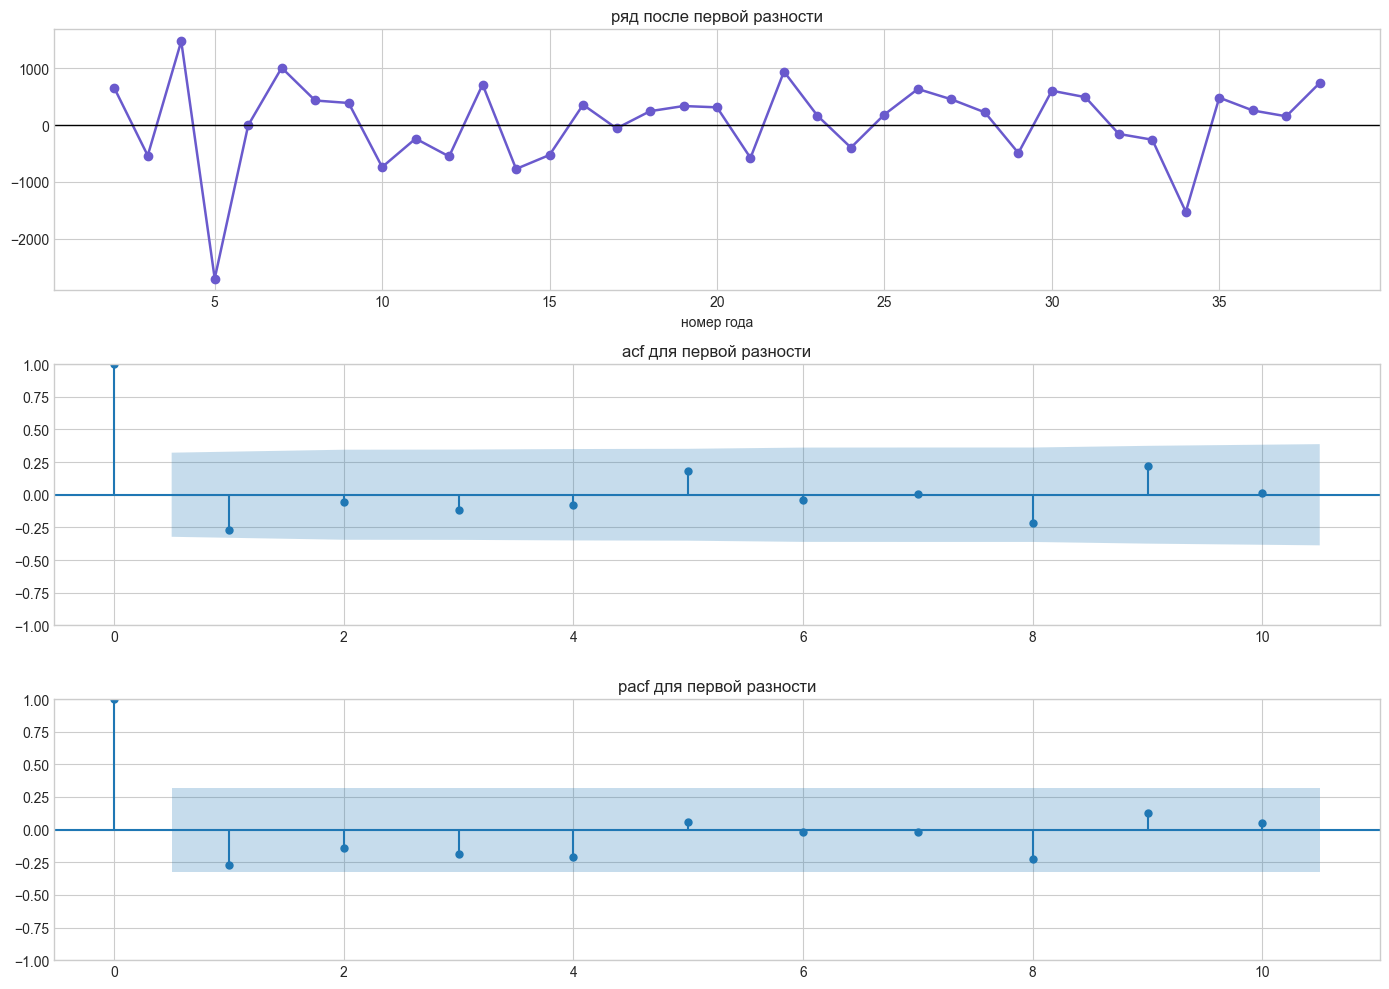

In [22]:
diff_series = diff_1.dropna()

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].plot(
    diff_series.index,
    diff_series.values,
    marker='o',
    linewidth=1.8,
    color='slateblue',
)
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_title('ряд после первой разности')
axes[0].set_xlabel('номер года')

plot_acf(diff_series, lags=10, ax=axes[1])
axes[1].set_title('acf для первой разности')

plot_pacf(diff_series, lags=10, ax=axes[2], method='ywm')
axes[2].set_title('pacf для первой разности')

plt.tight_layout()
plt.show()

## подбираем несколько моделей

чтобы не выбирать модель на глаз, я делаю небольшой перебор:
- `p` от 0 до 3;
- `d` от 0 до 2;
- `q` от 0 до 3.

оценка идет по последним 4 точкам, которые я заранее убрал из обучения.
для каждой модели считаю:
- `mae`;
- `rmse`;
- `mape`;
- `aic` и `bic`;
- `ljung-box` по остаткам.

In [23]:
def evaluate_orders(train_values, valid_values, p_max=3, d_max=2, q_max=3):
    rows = []
    ljung_box_lag = min(10, max(3, len(train_values) // 3))

    for d in range(d_max + 1):
        for p in range(p_max + 1):
            for q in range(q_max + 1):
                if p == 0 and d == 0 and q == 0:
                    continue

                try:
                    model = ARIMA(
                        train_values,
                        order=(p, d, q),
                        enforce_stationarity=False,
                        enforce_invertibility=False,
                    )
                    fit = model.fit()
                    forecast = fit.forecast(steps=len(valid_values))

                    mae = np.mean(np.abs(valid_values.values - forecast.values))
                    rmse = np.sqrt(np.mean((valid_values.values - forecast.values) ** 2))
                    mape = np.mean(
                        np.abs((valid_values.values - forecast.values) / valid_values.values)
                    ) * 100

                    ljung_box_pvalue = acorr_ljungbox(
                        fit.resid.dropna(),
                        lags=[ljung_box_lag],
                        return_df=True,
                    )['lb_pvalue'].iloc[0]

                    rows.append(
                        {
                            'order': (p, d, q),
                            'aic': fit.aic,
                            'bic': fit.bic,
                            'mae': mae,
                            'rmse': rmse,
                            'mape, %': mape,
                            'ljung-box p-value': ljung_box_pvalue,
                            'сошлась': fit.mle_retvals.get('converged', True),
                        }
                    )
                except Exception:
                    pass

    result = pd.DataFrame(rows)
    result = result.sort_values(by=['rmse', 'aic']).reset_index(drop=True)
    return result


candidate_table = evaluate_orders(train, valid)
display(candidate_table.head(12))

,order,aic,bic,mae,rmse,"mape, %",ljung-box p-value,сошлась
0,"(3, 1, 1)",485.078,492.084,322.242,371.433,4.589,0.812,True
1,"(3, 2, 2)",461.601,469.805,284.414,405.152,3.964,0.238,True
2,"(3, 1, 2)",485.546,493.953,301.065,416.476,4.200,0.914,True
3,"(3, 2, 3)",448.327,457.652,291.778,419.442,4.066,0.541,True
4,"(1, 1, 2)",481.658,487.263,313.397,423.537,4.376,0.911,True
5,"(2, 1, 1)",504.964,510.700,278.784,427.205,3.851,0.943,True
6,"(3, 2, 1)",459.641,466.478,279.437,429.871,3.870,0.270,True
7,"(0, 1, 2)",483.920,488.124,253.155,432.100,3.434,0.937,True
8,"(1, 1, 1)",503.102,507.404,291.449,451.737,4.020,0.940,True
9,"(3, 1, 0)",485.356,490.961,341.858,467.997,4.780,0.842,True


## какую модель беру

по таблице лучшей оказалась `arima(3, 1, 1)`:
- у нее минимальный `rmse` на holdout;
- `ljung-box` не показывает проблемной автокорреляции остатков;
- `d=1` хорошо согласуется с adf-проверкой.

выбранная модель: (3, 1, 1)


,order,aic,bic,mae,rmse,"mape, %",ljung-box p-value,сошлась
0,"(3, 1, 1)",485.078,492.084,322.242,371.433,4.589,0.812,True


,номер года,факт,прогноз,ошибка,abs ошибка
0,35,"6,346.700","6,450.160",-103.460,103.460
1,36,"6,606.100","6,830.490",-224.390,224.390
2,37,"6,762.700","7,123.020",-360.320,360.320
3,38,"7,507.400","6,906.590",600.810,600.810


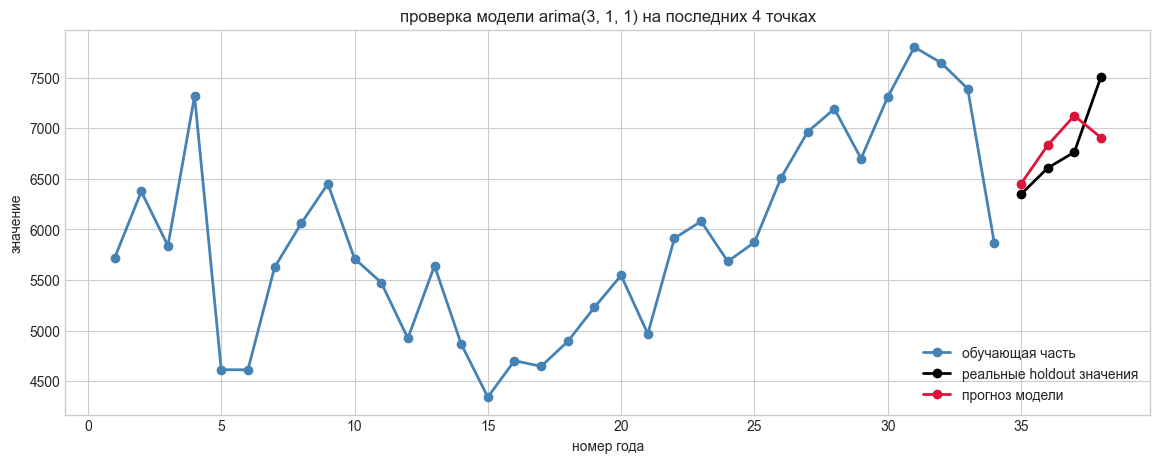

,лаг,статистика ljung-box,p-value
0,5,5.718,0.335
1,10,6.040,0.812


In [24]:
converged_table = candidate_table[candidate_table['сошлась']].reset_index(drop=True)
selected_row = converged_table.iloc[0]
selected_order = tuple(selected_row['order'])

print('выбранная модель:', selected_order)
display(pd.DataFrame([selected_row]))

selected_fit = ARIMA(
    train,
    order=selected_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit()

validation_forecast = selected_fit.forecast(steps=len(valid))

validation_table = pd.DataFrame(
    {
        'номер года': valid.index,
        'факт': valid.values,
        'прогноз': validation_forecast.values,
        'ошибка': valid.values - validation_forecast.values,
    }
)
validation_table['abs ошибка'] = np.abs(validation_table['ошибка'])

display(validation_table.round(2))

plt.figure(figsize=(14, 5))

plt.plot(
    train.index,
    train.values,
    marker='o',
    linewidth=2,
    color='steelblue',
    label='обучающая часть',
)

plt.plot(
    valid.index,
    valid.values,
    marker='o',
    linewidth=2,
    color='black',
    label='реальные holdout значения',
)

plt.plot(
    valid.index,
    validation_forecast.values,
    marker='o',
    linewidth=2,
    color='crimson',
    label='прогноз модели',
)

plt.title(f'проверка модели arima{selected_order} на последних 4 точках')
plt.xlabel('номер года')
plt.ylabel('значение')
plt.legend()
plt.show()

residual_lb_table = acorr_ljungbox(
    selected_fit.resid.dropna(),
    lags=[5, 10],
    return_df=True,
).reset_index().rename(
    columns={
        'index': 'лаг',
        'lb_stat': 'статистика ljung-box',
        'lb_pvalue': 'p-value',
    }
)

display(residual_lb_table)

## финальный прогноз на 4 года вперед

после проверки модели на holdout я переобучаю ее уже на всем доступном ряде и строю прогноз на следующие 4 шага.

,номер будущего года,прогноз
0,39,"7,145.690"
1,40,"6,960.470"
2,41,"6,819.310"
3,42,"6,920.510"


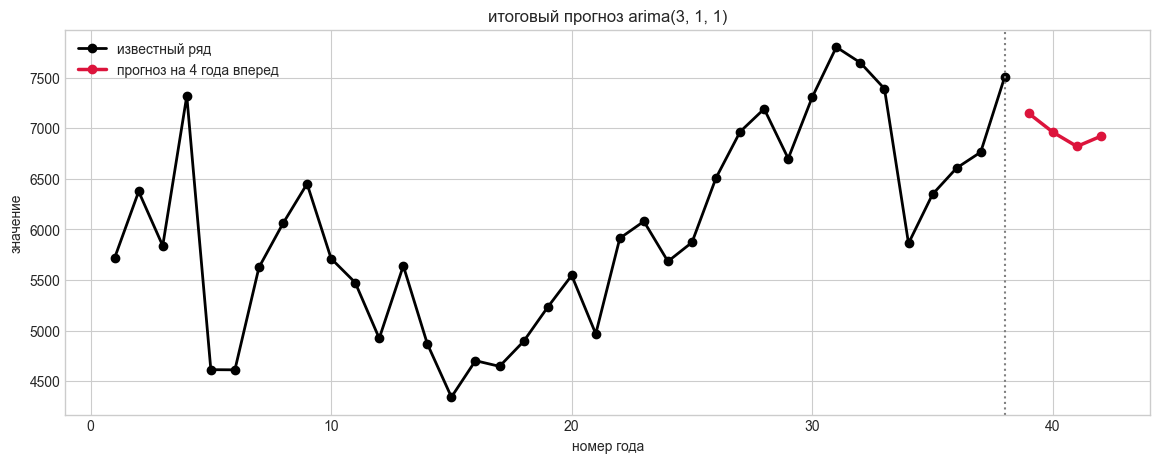

In [25]:
final_fit = ARIMA(
    series,
    order=selected_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit()

future_forecast = final_fit.forecast(steps=4)
future_steps = np.arange(series.index.max() + 1, series.index.max() + 5)

forecast_table = pd.DataFrame(
    {
        'номер будущего года': future_steps,
        'прогноз': future_forecast.values,
    }
)

display(forecast_table.round(2))

plt.figure(figsize=(14, 5))

plt.plot(
    series.index,
    series.values,
    marker='o',
    linewidth=2,
    color='black',
    label='известный ряд',
)

plt.plot(
    future_steps,
    future_forecast.values,
    marker='o',
    linewidth=2.5,
    color='crimson',
    label='прогноз на 4 года вперед',
)

plt.axvline(series.index.max(), color='gray', linestyle=':', linewidth=1.5)
plt.title(f'итоговый прогноз arima{selected_order}')
plt.xlabel('номер года')
plt.ylabel('значение')
plt.legend()
plt.show()

## вывод

для ряда исходный уровень оказался нестационарным, поэтому сначала понадобилось дифференцирование.
после сравнения набора моделей лучшей по holdout стала arima(3, 1, 1)